In [1]:
!pip install corus pymorphy3 razdel nltk tqdm scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.7/83.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 32.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import re
from functools import lru_cache
from itertools import islice
from razdel import tokenize
import pymorphy3
from corus import load_lenta
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

RANDOM_STATE = 2026
np.random.seed(RANDOM_STATE)

Загрузка данных и выборка 100_000 текстов

In [3]:
!wget -q https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz

In [4]:
path = 'lenta-ru-news.csv.gz'
data = list(islice(load_lenta(path), 100_000))
df = pd.DataFrame([{'text': r.text, 'topic': r.topic} for r in data])
df = df.dropna()

Предобработка текстов с razdel и pymorphy3

In [5]:
morph = pymorphy3.MorphAnalyzer()

@lru_cache(maxsize=100_000)
def lemmatize(token):
    return morph.parse(token)[0].normal_form

def preprocess(text):
    if not isinstance(text, str):
        return ''

    text = text.lower()

    tokens = [t.text for t in tokenize(text)]

    tokens = [t for t in tokens if re.match(r'^[а-яё]+$', t)]

    tokens = [lemmatize(t) for t in tokens if t]

    return ' '.join(tokens)

Для предобработки текстов был выбран достаточно простой пайплайн, подходящий для русскоязычной новостной классификации. Сначала текст приводится к нижнему регистру, чтобы одинаковые слова с разным написанием не считались разными признаками. Затем используется токенизация через razdel, razdel был выбран т.к он показывает около sota значения на русском языке при большой скорости обработки. После токенизации удаляются все токены, кроме русских слов: числа, знаки препинания, латиница и служебные символы в данной задаче скорее добавляют шум, который например тут может появиться в результате парсинга в ходе создания датасета. Далее применяется лемматизация с помощью pymorphy3: слова приводятся к начальной форме, что уменьшает размер словаря и объединяет разные формы одного слова. Стемминг не использовался, потому что он грубее обрезает слова и может давать менее интерпретируемые признаки. Кроме того сам pymorphy3 был рекомендован на лекции. Для ускорения повторная лемматизация одинаковых токенов кэшируется через lru_cache.



Распределение классов

In [6]:
print("Распределение классов:")
print(df['topic'].value_counts())
print(f"\nКоличество классов: {df['topic'].nunique()}")
print(f"Минимальное количество в классе: {df['topic'].value_counts().min()}")

Распределение классов:
topic
Россия               15151
Мир                  14421
Спорт                10045
Экономика             7682
Интернет и СМИ        6935
Силовые структуры     6925
Бывший СССР           6810
Культура              6578
Наука и техника       5645
Из жизни              4903
Ценности              4480
Дом                   3408
Путешествия           3223
Бизнес                1993
69-я параллель         815
Крым                   661
Культпросвет           307
                        17
Оружие                   1
Name: count, dtype: int64

Количество классов: 19
Минимальное количество в классе: 1


In [7]:

df['text_clean'] = [preprocess(text) for text in tqdm(df['text'], desc='Preprocessing', total=len(df))]
df['topic'] = df['topic'].astype('category')

print(f"Обработано {len(df)} текстов")
X = df['text_clean']
y = df['topic']


Preprocessing:   0%|          | 0/100000 [00:00<?, ?it/s]

Обработано 100000 текстов


Очистка и фильтрация датасета

In [8]:
# Пропускаем неразмеченные примеры
min_samples = 10
class_counts = df['topic'].value_counts()
valid_classes = class_counts[class_counts >= min_samples].index.tolist()

print(f"Классов всего: {len(class_counts)}")
print(f"Классов с {min_samples}+ примеров: {len(valid_classes)}")
print(f"Отфильтрованные классы:")
for cls in class_counts.index:
    if cls not in valid_classes:
        print(f"  - '{cls}': {class_counts[cls]} примеров")

# Фильтруем датафрейм
df = df[df['topic'].isin(valid_classes)].reset_index(drop=True)
print(f"\nОсталось записей: {len(df)}")

Классов всего: 19
Классов с 10+ примеров: 18
Отфильтрованные классы:
  - 'Оружие': 1 примеров

Осталось записей: 99999


Разделение на train/val/test (60/20/20) со стратификацией и проверкой ее корректности

In [9]:
df['topic'] = df['topic'].astype('category')

classes = df['topic'].cat.categories.tolist()
y_encoded = df['topic'].cat.codes.values

In [10]:
# Проверка стратификации
print("=" * 60)
print("ПРОВЕРКА СТРАТИФИКАЦИИ")
print("=" * 60)

# Распределение до split
print("\n До split (весь датасет):")
dist_before = pd.Series(y_encoded).value_counts().sort_index()
for idx, count in dist_before.items():
    print(f"  {classes[idx]:20s}: {count:5d} ({count/len(y_encoded)*100:5.2f}%)")

# Выполняем split
X = df['text_clean']
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.4, random_state=RANDOM_STATE, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

# Распределение после split
print("\n После split:")
print(f"{'Класс':20s} | {'Train':>6s} ({'%' :>4s}) | {'Val':>5s} ({'%' :>4s}) | {'Test':>5s} ({'%' :>4s})")
print("-" * 60)

for i in range(len(classes)):
    total = dist_before.get(i, 0)
    train_count = np.sum(y_train == i)
    val_count = np.sum(y_val == i)
    test_count = np.sum(y_test == i)

    if total > 0:
        train_pct = train_count / total * 100
        val_pct = val_count / total * 100
        test_pct = test_count / total * 100
    else:
        train_pct = val_pct = test_pct = 0

    print(f"{classes[i]:20s} | {train_count:6d} ({train_pct:4.1f}%) | {val_count:5d} ({val_pct:4.1f}%) | {test_count:5d} ({test_pct:4.1f}%)")

print("-" * 60)
print(f"{'TOTAL':20s} | {len(y_train):6d} (100%) | {len(y_val):5d} (100%) | {len(y_test):5d} (100%)")

ПРОВЕРКА СТРАТИФИКАЦИИ

 До split (весь датасет):
                      :    17 ( 0.02%)
  69-я параллель      :   815 ( 0.82%)
  Бизнес              :  1993 ( 1.99%)
  Бывший СССР         :  6810 ( 6.81%)
  Дом                 :  3408 ( 3.41%)
  Из жизни            :  4903 ( 4.90%)
  Интернет и СМИ      :  6935 ( 6.94%)
  Крым                :   661 ( 0.66%)
  Культпросвет        :   307 ( 0.31%)
  Культура            :  6578 ( 6.58%)
  Мир                 : 14421 (14.42%)
  Наука и техника     :  5645 ( 5.65%)
  Путешествия         :  3223 ( 3.22%)
  Россия              : 15151 (15.15%)
  Силовые структуры   :  6925 ( 6.93%)
  Спорт               : 10045 (10.05%)
  Ценности            :  4480 ( 4.48%)
  Экономика           :  7682 ( 7.68%)

 После split:
Класс                |  Train (   %) |   Val (   %) |  Test (   %)
------------------------------------------------------------
                     |     10 (58.8%) |     4 (23.5%) |     3 (17.6%)
69-я параллель       |    489 (60.0

Dummy-бейзлайн (самый частый класс)

In [11]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_val)
dummy_proba = dummy.predict_proba(X_val)

print(f"Dummy Accuracy: {accuracy_score(y_val, dummy_pred):.4f}")
print(f"Dummy ROC AUC (macro): {roc_auc_score(y_val, dummy_proba, average='macro', multi_class='ovr'):.4f}")
print(f"Dummy PR AUC (macro): {average_precision_score(y_val, dummy_proba, average='macro'):.4f}")

Dummy Accuracy: 0.1515
Dummy ROC AUC (macro): 0.5000
Dummy PR AUC (macro): 0.0556


Логистическая регрессия с CountVectorizer

In [12]:
count_vec = CountVectorizer(max_features=5000)
X_train_count = count_vec.fit_transform(X_train)
X_val_count = count_vec.transform(X_val)

lr_count = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, n_jobs=-1)
lr_count.fit(X_train_count, y_train)
count_pred = lr_count.predict(X_val_count)
count_proba = lr_count.predict_proba(X_val_count)

print(f"CountVectorizer Accuracy: {accuracy_score(y_val, count_pred):.4f}")
print(f"CountVectorizer ROC AUC (macro): {roc_auc_score(y_val, count_proba, average='macro', multi_class='ovr'):.4f}")
print(f"CountVectorizer PR AUC (macro): {average_precision_score(y_val, count_proba, average='macro'):.4f}")

CountVectorizer Accuracy: 0.8040
CountVectorizer ROC AUC (macro): 0.9476
CountVectorizer PR AUC (macro): 0.7722


Логистическая регрессия с TfidfVectorizer

In [13]:
tfidf_vec = TfidfVectorizer(max_features=5000) # одинаковое с CountVectorizer
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_val_tfidf = tfidf_vec.transform(X_val)

lr_tfidf = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, n_jobs=-1)
lr_tfidf.fit(X_train_tfidf, y_train)
tfidf_pred = lr_tfidf.predict(X_val_tfidf)
tfidf_proba = lr_tfidf.predict_proba(X_val_tfidf)

print(f"TfidfVectorizer Accuracy: {accuracy_score(y_val, tfidf_pred):.4f}")
print(f"TfidfVectorizer ROC AUC (macro): {roc_auc_score(y_val, tfidf_proba, average='macro', multi_class='ovr'):.4f}")
print(f"TfidfVectorizer PR AUC (macro): {average_precision_score(y_val, tfidf_proba, average='macro'):.4f}")

TfidfVectorizer Accuracy: 0.8244
TfidfVectorizer ROC AUC (macro): 0.9765
TfidfVectorizer PR AUC (macro): 0.8007


Подбор гиперпараметров для лучшего варианта (TF-IDF + LR) при помощи gridsearch

In [14]:
param_grid = {
    'vectorizer__min_df': [5, 15],
    'vectorizer__max_features': [4000, 8000],
    'classifier__C': [0.1, 1, 10]
}

pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, n_jobs=-1))
])

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='roc_auc_ovr',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"Best Params: {grid_search.best_params_}")
print(f"Best CV ROC AUC: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params: {'classifier__C': 1, 'vectorizer__max_features': 8000, 'vectorizer__min_df': 5}
Best CV ROC AUC: 0.9794


Для улучшения качества модели подбирались параметры как векторизатора, так и логистической регрессии. В TfidfVectorizer варьировался параметр min_df, который задает минимальное число документов, где должно встретиться слово. Значения 5 и 15 позволяют отфильтровать слишком редкие токены: они часто являются опечатками, именами или случайным шумом и могут ухудшать обобщающую способность модели. Также подбирался max_features, ограничивающий размер словаря. Значения 4000 и 8000 выбраны как разумный компромисс между информативностью признаков, скоростью обучения и риском переобучения. Для LogisticRegression подбирался параметр C, отвечающий за силу регуляризации. Значения 0.1, 1 и 10 позволяют проверить модели от более строгой регуляризации до более свободной. Подбор выполнялся через кросс-валидацию, чтобы выбрать параметры не по одному случайному разбиению, а по более устойчивой оценке качества.

Оценка на валидационной выборке

In [15]:
best_model = grid_search.best_estimator_
val_pred = best_model.predict(X_val)
val_proba = best_model.predict_proba(X_val)

print(f"Best Model Accuracy: {accuracy_score(y_val, val_pred):.4f}")
print(f"Best Model ROC AUC (macro): {roc_auc_score(y_val, val_proba, average='macro', multi_class='ovr'):.4f}")
print(f"Best Model PR AUC (macro): {average_precision_score(y_val, val_proba, average='macro'):.4f}")

Best Model Accuracy: 0.8278
Best Model ROC AUC (macro): 0.9765
Best Model PR AUC (macro): 0.8067


Оценка на отложенной тестовой выборке

In [16]:
test_pred = best_model.predict(X_test)
test_proba = best_model.predict_proba(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, test_pred):.4f}")
print(f"Test ROC AUC (macro): {roc_auc_score(y_test, test_proba, average='macro', multi_class='ovr'):.4f}")
print(f"Test PR AUC (macro): {average_precision_score(y_test, test_proba, average='macro'):.4f}")
unique_labels = np.unique(y_test)
classes_actual = [classes[i] for i in unique_labels]
print("\nClassification Report:")
print(classification_report(y_test, test_pred, labels=unique_labels, target_names=classes_actual))

Test Accuracy: 0.8347
Test ROC AUC (macro): 0.9678
Test PR AUC (macro): 0.8096

Classification Report:
                   precision    recall  f1-score   support

                        0.00      0.00      0.00         3
   69-я параллель       0.91      0.56      0.69       163
           Бизнес       0.68      0.41      0.51       399
      Бывший СССР       0.86      0.85      0.85      1362
              Дом       0.89      0.82      0.85       682
         Из жизни       0.80      0.79      0.79       981
   Интернет и СМИ       0.83      0.80      0.81      1387
             Крым       0.79      0.55      0.65       132
    Культпросвет        0.63      0.28      0.39        61
         Культура       0.87      0.89      0.88      1315
              Мир       0.83      0.90      0.86      2884
  Наука и техника       0.87      0.88      0.88      1129
      Путешествия       0.83      0.77      0.80       645
           Россия       0.76      0.82      0.79      3031
Силовые стр

Анализ ошибок - Confusion Matrix

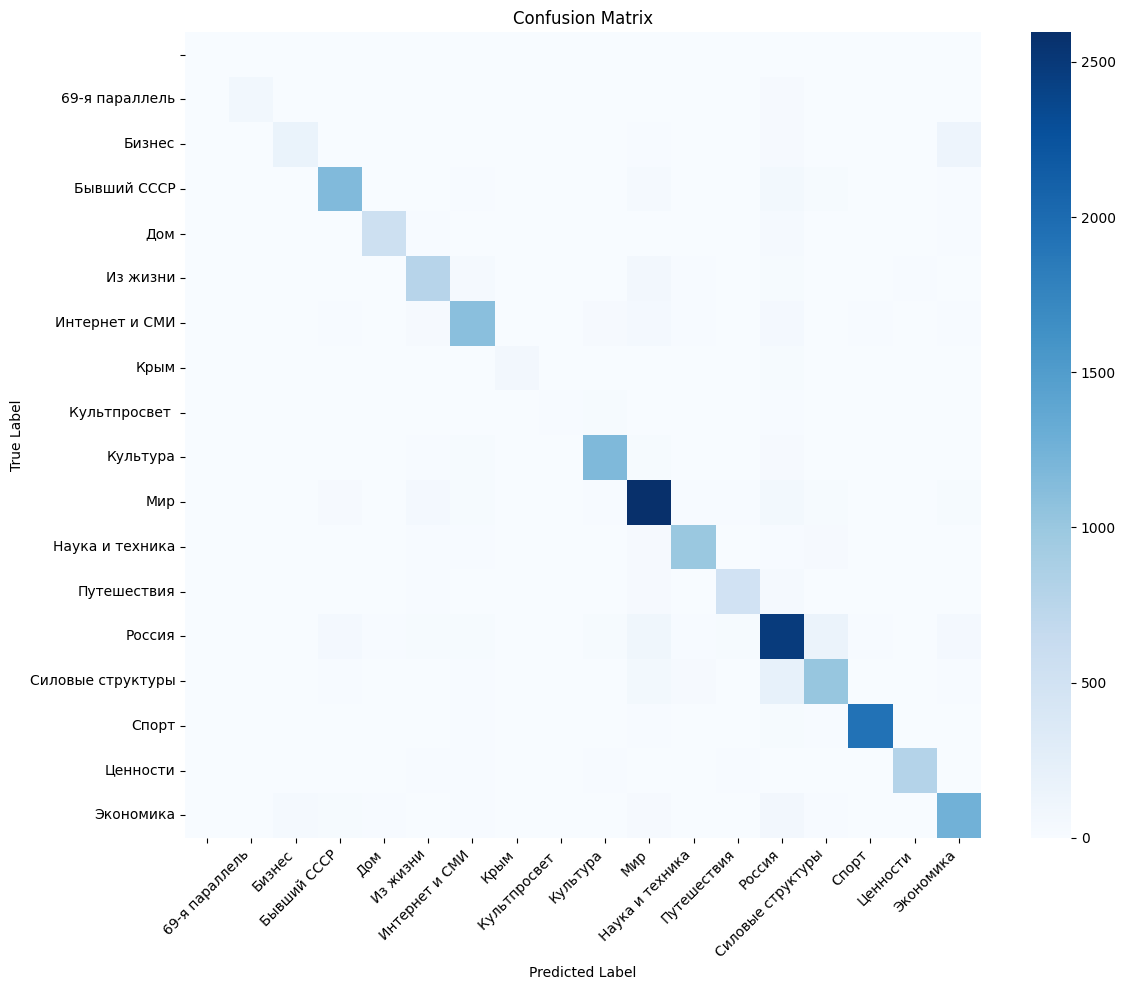

In [17]:
cm = confusion_matrix(y_test, test_pred, labels=unique_labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=classes_actual, yticklabels=classes_actual)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Примеры ошибок модели

In [18]:
df_test = pd.DataFrame({
    'text': X_test,
    'true': y_test,
    'pred': test_pred
})

class_mapper = {i: classes_actual[i] for i in range(len(classes_actual))}
full_mapper = {orig: classes[i] for i, orig in enumerate(unique_labels)}

df_test['true_name'] = df_test['true'].map(full_mapper)
df_test['pred_name'] = df_test['pred'].map(full_mapper)

errors = df_test[df_test['true'] != df_test['pred']].sample(10)
print(errors[['true_name', 'pred_name', 'text']].to_string())

            true_name        pred_name                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

В итоге можно добавить что несмотря на хорошее общее качество, существуют проблемы с определенными классами(Например Культпросвет), это может быть связано с малым количеством примеров в выборке. Если способность их определения нам не имеет большой ценности, можем их исключить из выборки.